# Laboratorio di Machine Learning per l’Analisi Finanziaria — Università Federico II
## Lezione 01 — Il churn come problema di classificazione: formulazione e analisi esplorativa

**Autori:** Enrico Huber, Pietro Soglia  \\n
**Email:** enricohuber5@gmail.com, pietro.soglia@gmail.com  \\n
**Ultimo aggiornamento:** 2026-03-02

## 1. Obiettivi di apprendimento

Al termine della lezione sarai in grado di:
- tradurre un problema di business (churn) in un problema di **classificazione** (feature, target, unità statistica)
- identificare tipologie di variabili tipiche in dati finanziari (numeriche, categoriche, binarie)
- eseguire una **EDA guidata** e comunicare evidenze (qualità del dato, distribuzioni, sbilanciamento, segmenti)
- formulare ipotesi iniziali su quali variabili possano essere predittive del churn
- riconoscere rischi comuni: leakage, target imbalance, metriche incoerenti

## 2. Setup

### Strumenti (cenni)
- **GenAI / Code Assistants**: utili per scaffolding e refactor, ma vanno usati con spirito critico (verifica risultati, niente ‘magia’).
- **Git & GitHub**: versionamento, collaborazione, Issues/Discussions e tracciabilità delle modifiche.

### Contratto di input/output (artifact-based)
Questo notebook legge:
- `data/archive.zip` (contiene `Customer-Churn-Records.csv`)

Questo notebook scrive (sezione 3–4):
- `outputs/data/lesson_01_raw.parquet` (se disponibile) **oppure** `outputs/data/lesson_01_raw.csv` (fallback)
- `outputs/figures/lesson_01_*.png` (figure EDA salvate con prefisso `lesson_01_`)
- `outputs/config/lesson_01_eda_summary.json` (riassunto EDA: metriche/segmenti principali)

In [2]:
from __future__ import annotations

from pathlib import Path
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Convenzioni di progetto
TARGET_COL = 'Exited'

plt.rcParams.update({
    'figure.figsize': (8, 4),
    'axes.grid': True,
})

def find_project_root(start: Path) -> Path:
    """Cerca la root del repo risalendo finché trova README.md e requirements.txt."""
    current = start.resolve()
    for parent in [current, *current.parents]:
        if (parent / 'README.md').exists() and (parent / 'requirements.txt').exists():
            return parent
    # fallback: cwd
    return current

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / 'data'
ARCHIVE_PATH = DATA_DIR / 'archive.zip'

OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
OUT_DATA_DIR = OUTPUTS_DIR / 'data'
OUT_CONFIG_DIR = OUTPUTS_DIR / 'config'
OUT_FIGURES_DIR = OUTPUTS_DIR / 'figures'

for d in [OUT_DATA_DIR, OUT_CONFIG_DIR, OUT_FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RAW_PARQUET_PATH = OUT_DATA_DIR / 'lesson_01_raw.parquet'
TARGET_DIST_FIG_PATH = OUT_FIGURES_DIR / 'lesson_01_target_distribution.png'

print('PROJECT_ROOT:', PROJECT_ROOT)
print('ARCHIVE_PATH:', ARCHIVE_PATH)
print('RAW_PARQUET_PATH:', RAW_PARQUET_PATH)

PROJECT_ROOT: C:\Users\ehuber\OneDrive - BUSINESS INTEGRATION PARTNERS SPA\projects\machine-learning-lab-2026
ARCHIVE_PATH: C:\Users\ehuber\OneDrive - BUSINESS INTEGRATION PARTNERS SPA\projects\machine-learning-lab-2026\data\archive.zip
RAW_PARQUET_PATH: C:\Users\ehuber\OneDrive - BUSINESS INTEGRATION PARTNERS SPA\projects\machine-learning-lab-2026\outputs\data\lesson_01_raw.parquet


## 3. Data loading

Carichiamo il dataset direttamente dall’archivio `.zip` senza estrarlo manualmente.
Mostriamo: shape, head, dtypes e un riepilogo della missingness.

In [3]:
if not ARCHIVE_PATH.exists():
    raise FileNotFoundError(f"Non trovo {ARCHIVE_PATH}. Assicurati di avere `data/archive.zip` nel repository.")

CSV_MEMBER = 'Customer-Churn-Records.csv'

def load_csv_from_zip(archive_path: Path, member_name: str) -> pd.DataFrame:
    with zipfile.ZipFile(archive_path, 'r') as zf:
        if member_name not in zf.namelist():
            raise FileNotFoundError(f"Il file '{member_name}' non è presente in {archive_path.name}. Contenuti: {zf.namelist()}")
        with zf.open(member_name) as f:
            return pd.read_csv(f)

df_raw = load_csv_from_zip(ARCHIVE_PATH, CSV_MEMBER)

print('Shape:', df_raw.shape)
display(df_raw.head())
display(df_raw.dtypes)

Shape: (10000, 18)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


RowNumber               int64
CustomerId              int64
Surname                   str
CreditScore             int64
Geography                 str
Gender                    str
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Exited                  int64
Complain                int64
Satisfaction Score      int64
Card Type                 str
Point Earned            int64
dtype: object

In [5]:
# Missingness overview
missing = (df_raw.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]

if len(missing) == 0:
    print('Nessun valore mancante (0% missing)')
else:
    display(missing.to_frame(name='missing_%'))

# Salva una copia efficiente dei dati grezzi (artifact)
try:
    df_raw.to_parquet(RAW_PARQUET_PATH, index=False)
    print('Salvato:', RAW_PARQUET_PATH)
except Exception as e:
    fallback_path = RAW_PARQUET_PATH.with_suffix('.csv')
    df_raw.to_csv(fallback_path, index=False)
    print('Parquet non disponibile (es. manca pyarrow).')
    print('Salvato fallback CSV:', fallback_path)
    print('Dettagli errore:', repr(e))

Nessun valore mancante (0% missing)
Parquet non disponibile (es. manca pyarrow).
Salvato fallback CSV: C:\Users\ehuber\OneDrive - BUSINESS INTEGRATION PARTNERS SPA\projects\machine-learning-lab-2026\outputs\data\lesson_01_raw.csv
Dettagli errore: ImportError("Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.\nA suitable version of pyarrow or fastparquet is required for parquet support.\nTrying to import the above resulted in these errors:\n - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.\n - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.")


## 4. Analisi esplorativa (EDA)

In questa lezione ci concentriamo su:
- distribuzione del target
- statistiche descrittive
- feature principali (numeriche e categoriche)
- verifica di eventuale sbilanciamento

Nota: l’obiettivo è costruire un quadro descrittivo dei dati (tabelle + grafici) e individuare pattern/criticità da approfondire.

### 4.1 Qualità del dataset (sanity checks)

Prima di guardare i grafici, verifichiamo alcune cose basilari:
- duplicati di righe e di chiavi (`CustomerId`)
- colonne “ID-like” (alta cardinalità: spesso non vanno in feature)
- colonne costanti o quasi-costanti
- tipologie (numeriche vs categoriche) e cardinalità delle categoriche

In [7]:
# Shape, dtypes, head
print('Shape:', df_raw.shape)
display(df_raw.head())
display(df_raw.dtypes.to_frame('dtype'))

# Missingness
missing = (df_raw.isna().mean() * 100).sort_values(ascending=False)
if float(missing.max()) == 0.0:
    print('Nessun valore mancante (0% missing)')
else:
    display(missing.to_frame('missing_%'))

# Duplicati (righe e CustomerId se presente)
n_dup_rows = int(df_raw.duplicated().sum())
print('Duplicati di righe:', n_dup_rows)

if 'CustomerId' in df_raw.columns:
    n_dup_customer = int(df_raw['CustomerId'].duplicated().sum())
    print('Duplicati di CustomerId:', n_dup_customer)

# Cardinalità (quanti valori distinti per colonna)
n_rows, n_cols = df_raw.shape
nunique = df_raw.nunique(dropna=False).sort_values(ascending=False)
display(nunique.to_frame('n_unique'))

# Colonne costanti
constant_cols = nunique[nunique <= 1].index.tolist()
if len(constant_cols) > 0:
    print('Colonne costanti:', constant_cols)
else:
    print('Nessuna colonna costante')

# Colonne “ID-like”: alta unicità su colonne discrete (interi/stringhe)
print("Nota: variabili continue (float) possono avere molti valori unici senza essere ID.")
id_like_cols = []
for col, n_u in nunique.items():
    if col == TARGET_COL:
        continue
    if n_u >= 0.95 * n_rows:
        is_discrete = pd.api.types.is_integer_dtype(df_raw[col]) or pd.api.types.is_object_dtype(df_raw[col])
        if is_discrete:
            id_like_cols.append(col)

print('Colonne ID-like (>=95% unici, discrete):', id_like_cols)

# Cardinalità delle categoriche (utile per capire complessità delle categorie)
cat_cols_all = df_raw.select_dtypes(include=['object', 'string']).columns.tolist()
if len(cat_cols_all) == 0:
    print('Nessuna colonna categorica di tipo object/string')
else:
    card = nunique[cat_cols_all].sort_values(ascending=False)
    display(card.to_frame('n_unique'))

Shape: (10000, 18)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


,dtype
RowNumber,int64
CustomerId,int64
Surname,str
CreditScore,int64
Geography,str
Gender,str
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64


Nessun valore mancante (0% missing)
Duplicati di righe: 0
Duplicati di CustomerId: 0


,n_unique
RowNumber,10000
CustomerId,10000
EstimatedSalary,9999
Balance,6382
Surname,2932
Point Earned,785
CreditScore,460
Age,70
Tenure,11
Satisfaction Score,5


Nessuna colonna costante
Nota: variabili continue (float) possono avere molti valori unici senza essere ID.
Colonne ID-like (>=95% unici, discrete): ['RowNumber', 'CustomerId']


,n_unique
Surname,2932
Card Type,4
Geography,3
Gender,2


**Osservazioni (qualità dati)**

- Il dataset ha **10.000 righe** e **18 colonne**; non troviamo duplicati di righe né duplicati di `CustomerId` → buona qualità di base per l’analisi.
- Non ci sono colonne costanti: tutte le feature hanno almeno un po’ di variabilità.
- Le colonne **ID-like** rilevate sono `RowNumber` e `CustomerId`: sono identificativi (utili per tracciare i record), ma di solito non aggiungono informazione descrittiva sul cliente.
- Tra le categoriche, `Surname` ha **cardinalità molto alta (2932 valori)**: è un campanello d’allarme perché rende difficile riassumere il comportamento per “categoria”. Vale la pena controllare se contiene informazione reale o se è rumore/identificativo mascherato.
- `Geography` (3) e `Gender` (2) hanno cardinalità bassa: sono ottime variabili per segmentare e confrontare tassi di churn tra gruppi.

,count,perc_%
Exited,,
0,7962,79.62
1,2038,20.38


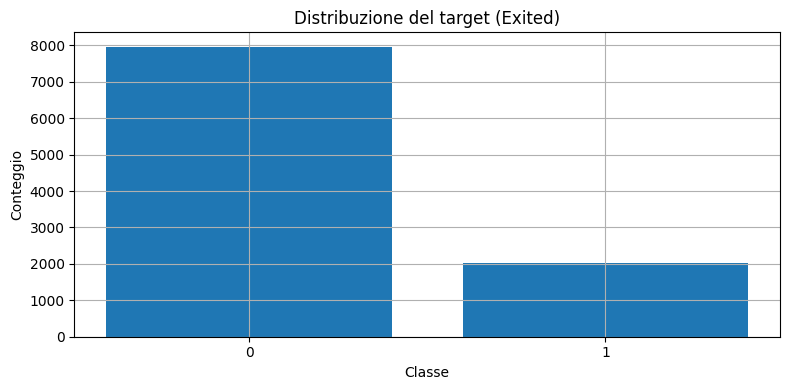

Salvata figura: C:\Users\ehuber\OneDrive - BUSINESS INTEGRATION PARTNERS SPA\projects\machine-learning-lab-2026\outputs\figures\lesson_01_target_distribution.png


In [30]:
# Target: nel dataset è tipicamente `Exited` (0/1)
try:
    target_col = TARGET_COL
except NameError:
    target_col = 'Exited'

if target_col not in df_raw.columns:
    raise KeyError(f"Colonna target '{target_col}' non trovata. Colonne: {list(df_raw.columns)}")
target_counts = df_raw[target_col].value_counts(dropna=False).sort_index()
target_perc = target_counts / len(df_raw) * 100

display(pd.DataFrame({'count': target_counts, 'perc_%': target_perc.round(2)}))

fig, ax = plt.subplots()
ax.bar(target_counts.index.astype(str), target_counts.values)
ax.set_title(f'Distribuzione del target ({target_col})')
ax.set_xlabel('Classe')
ax.set_ylabel('Conteggio')
fig.tight_layout()
fig.savefig(TARGET_DIST_FIG_PATH, dpi=150)
plt.show()
print('Salvata figura:', TARGET_DIST_FIG_PATH)

**Interpretazione (target e sbilanciamento)**

- Qui la churn (`Exited=1`) è **20,38%** (2038 su 10.000), mentre `Exited=0` è **79,62%**.
- Questo tasso “di base” è un numero chiave: quando confrontiamo segmenti (es. per Paese o per età) conviene sempre ricordare qual è la media complessiva.
- Lo sbilanciamento ~80/20 rende importante ragionare in termini di **tassi** e **conteggi** (non solo “impressioni” visive): differenze di pochi punti percentuali possono comunque coinvolgere molte persone.

In [8]:
# Statistiche descrittive (numeriche)
display(df_raw.describe(include='number').T)

# Statistiche per classe (media per feature numeriche)
num_cols = df_raw.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != TARGET_COL]

group_means = df_raw.groupby(TARGET_COL)[num_cols].mean(numeric_only=True)
display(group_means.T.sort_values(by=1, ascending=False).head(15))

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


Exited,0,1
CustomerId,1.569117e+07,1.569006e+07
EstimatedSalary,9.972685e+04,1.015099e+05
Balance,7.274275e+04,9.110948e+04
RowNumber,5.024073e+03,4.908407e+03
CreditScore,6.518379e+02,6.454146e+02
Point Earned,6.070441e+02,6.044485e+02
Age,3.740806e+01,4.483562e+01
Tenure,5.032781e+00,4.934740e+00
Satisfaction Score,3.017960e+00,2.997547e+00
NumOfProducts,1.544210e+00,1.475466e+00


**Spunti dai confronti per classe (medie numeriche)**

Le medie per classe (tabella sopra) suggeriscono alcune differenze interessanti (da verificare con grafici/segmentazioni):

- `Age`: in media i churner sono **più anziani** (circa **44,84** vs **37,41**).
- `Balance`: in media è **più alto** per `Exited=1` (circa **91.109** vs **72.743**).
- `IsActiveMember`: la quota di attivi è **più bassa** tra i churner (circa **0,361** vs **0,555**).
- `Complain`: differenza enorme (**~0,998** per `Exited=1` vs **~0,001** per `Exited=0`). Questo è un fortissimo indizio di **leakage**: la variabile potrebbe essere osservabile *dopo* (o in concomitanza di) una decisione di churn.

Nota: `CustomerId` e `RowNumber` compaiono perché sono numeriche, ma sono **identificativi**: è meglio non interpretarli come “driver” del churn.

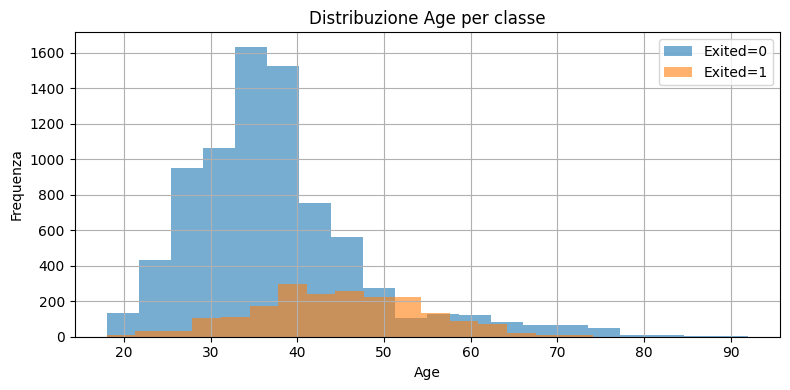

In [9]:
# Esempio: distribuzione età per classe
if 'Age' in df_raw.columns:
    fig, ax = plt.subplots()
    for cls, color in [(0, 'tab:blue'), (1, 'tab:orange')]:
        subset = df_raw.loc[df_raw[TARGET_COL] == cls, 'Age']
        ax.hist(subset, bins=20, alpha=0.6, label=f'{TARGET_COL}={cls}', color=color)
    ax.set_title('Distribuzione Age per classe')
    ax.set_xlabel('Age')
    ax.set_ylabel('Frequenza')
    ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print('Colonna Age non presente: salto il grafico.')

**Interpretazione (Age)**

- La distribuzione di `Age` tende a essere “spostata a destra” per `Exited=1`: coerente con la differenza nelle medie osservata sopra.
- Messaggio chiave: anche se la differenza è evidente, le due distribuzioni **si sovrappongono molto** → non esiste una soglia perfetta su `Age` da sola.
- Spunto per gli studenti: provare a guardare il churn rate per **fasce** di età (quantili) per capire se l’effetto è monotono o se ci sono soglie/segmenti (es. “over 50”).

### 4.2 Distribuzioni numeriche per classe

Qui esploriamo alcune variabili numeriche chiave confrontando `Exited=0` vs `Exited=1`.
Obiettivo: capire se ci sono spostamenti di distribuzione (non è ancora “validazione causale”).

In [10]:
def plot_hist_by_target(df: pd.DataFrame, col: str, target_col: str, bins: int, out_path: Path) -> None:
    """Istogramma sovrapposto per una feature numerica, separando per classe target."""
    fig, ax = plt.subplots()
    for cls, color in [(0, 'tab:blue'), (1, 'tab:orange')]:
        subset = df.loc[df[target_col] == cls, col].dropna()
        ax.hist(subset, bins=bins, alpha=0.6, label=f'{target_col}={cls}', color=color)
    ax.set_title(f'Distribuzione {col} per classe')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequenza')
    ax.legend()
    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.show()
    print('Salvata figura:', out_path)

# Esempi di variabili numeriche importanti
NUM_PLOT_COLS = [c for c in ['Balance', 'CreditScore', 'EstimatedSalary'] if c in df_raw.columns]
print('Colonne numeriche plottate:', NUM_PLOT_COLS)

Colonne numeriche plottate: ['Balance', 'CreditScore', 'EstimatedSalary']


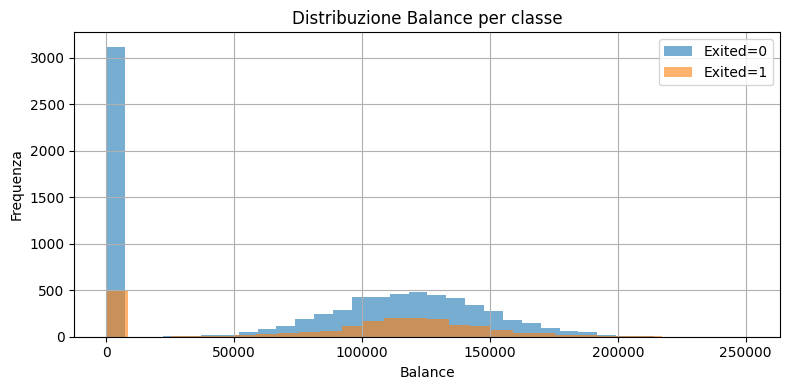

Salvata figura: C:\Users\ehuber\OneDrive - BUSINESS INTEGRATION PARTNERS SPA\projects\machine-learning-lab-2026\outputs\figures\lesson_01_balance_hist_by_class.png


In [11]:
# Plot 1: Balance
if 'Balance' in df_raw.columns:
    plot_hist_by_target(
        df_raw,
        col='Balance',
        target_col=TARGET_COL,
        bins=30,
        out_path=OUT_FIGURES_DIR / 'lesson_01_balance_hist_by_class.png',
    )

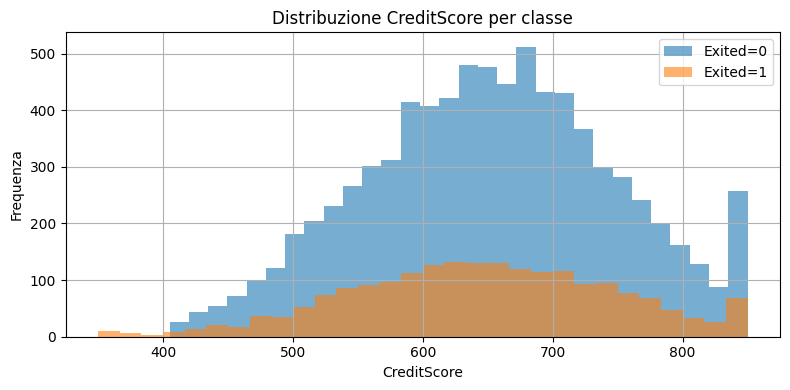

Salvata figura: C:\Users\ehuber\OneDrive - BUSINESS INTEGRATION PARTNERS SPA\projects\machine-learning-lab-2026\outputs\figures\lesson_01_credit_score_hist_by_class.png


In [12]:
# Plot 2: CreditScore
if 'CreditScore' in df_raw.columns:
    plot_hist_by_target(
        df_raw,
        col='CreditScore',
        target_col=TARGET_COL,
        bins=30,
        out_path=OUT_FIGURES_DIR / 'lesson_01_credit_score_hist_by_class.png',
    )

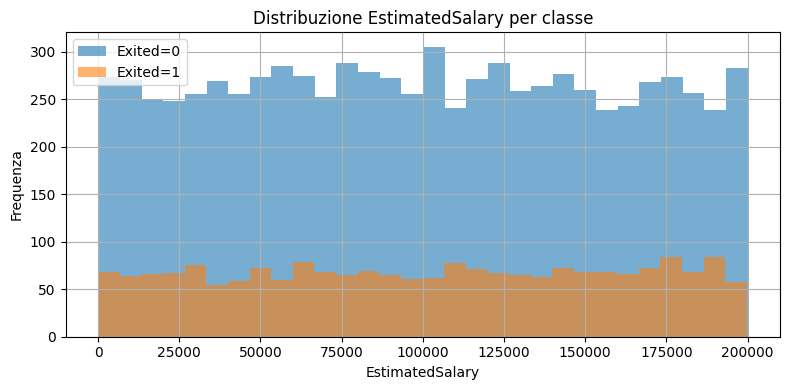

Salvata figura: C:\Users\ehuber\OneDrive - BUSINESS INTEGRATION PARTNERS SPA\projects\machine-learning-lab-2026\outputs\figures\lesson_01_estimated_salary_hist_by_class.png


In [13]:
# Plot 3: EstimatedSalary
if 'EstimatedSalary' in df_raw.columns:
    plot_hist_by_target(
        df_raw,
        col='EstimatedSalary',
        target_col=TARGET_COL,
        bins=30,
        out_path=OUT_FIGURES_DIR / 'lesson_01_estimated_salary_hist_by_class.png',
    )

**Interpretazione (feature numeriche: Balance, CreditScore, EstimatedSalary)**

- `Balance`: è una delle feature che separa meglio le classi in media (circa **91k** vs **73k**). Nei grafici spesso si nota anche un “muro” a `Balance=0`: può essere utile trattare `Balance==0` come un **segmento** (indicatore binario) oltre al valore continuo.
- `CreditScore`: la differenza tra classi è più piccola (medie ~**645** vs ~**652**) → effetto debole, ma potrebbe diventare più chiaro se guardiamo segmenti o relazioni con altre variabili.
- `EstimatedSalary`: medie molto vicine (~**101,5k** vs ~**99,7k**) → da sola non sembra un forte segnale.

Messaggio EDA: quando due distribuzioni si sovrappongono molto, è più informativo combinare più viste (istogrammi, boxplot, segmenti per fasce) invece di cercare una “regola” su una singola variabile.

C:\Users\ehuber\AppData\Local\Temp\ipykernel_30080\4156277139.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data0, data1], labels=[f'{TARGET_COL}=0', f'{TARGET_COL}=1'])
C:\Users\ehuber\AppData\Local\Temp\ipykernel_30080\4156277139.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data0, data1], labels=[f'{TARGET_COL}=0', f'{TARGET_COL}=1'])


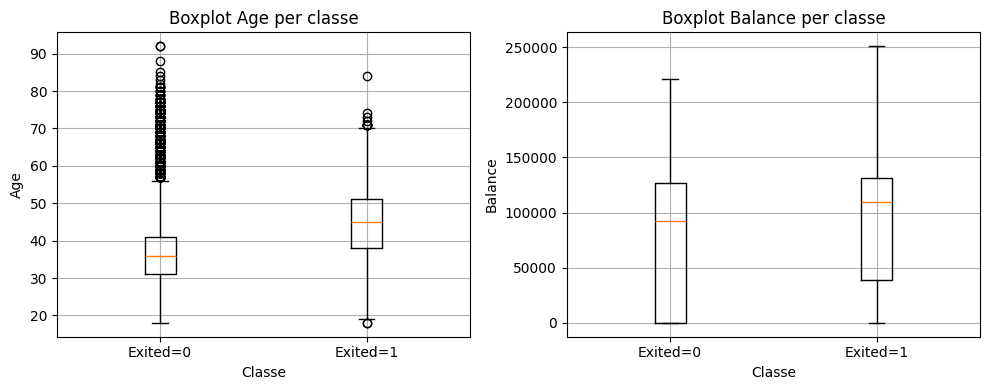

Salvata figura: C:\Users\ehuber\OneDrive - BUSINESS INTEGRATION PARTNERS SPA\projects\machine-learning-lab-2026\outputs\figures\lesson_01_boxplots_age_balance.png


In [14]:
# Boxplot (esempio): Age e Balance per classe
cols_for_box = [c for c in ['Age', 'Balance'] if c in df_raw.columns]
if len(cols_for_box) > 0:
    fig, axes = plt.subplots(1, len(cols_for_box), figsize=(5 * len(cols_for_box), 4), sharey=False)
    if len(cols_for_box) == 1:
        axes = [axes]
    for ax, col in zip(axes, cols_for_box):
        data0 = df_raw.loc[df_raw[TARGET_COL] == 0, col].dropna()
        data1 = df_raw.loc[df_raw[TARGET_COL] == 1, col].dropna()
        ax.boxplot([data0, data1], labels=[f'{TARGET_COL}=0', f'{TARGET_COL}=1'])
        ax.set_title(f'Boxplot {col} per classe')
        ax.set_xlabel('Classe')
        ax.set_ylabel(col)
    fig.tight_layout()
    out_path = OUT_FIGURES_DIR / 'lesson_01_boxplots_age_balance.png'
    fig.savefig(out_path, dpi=150)
    plt.show()
    print('Salvata figura:', out_path)

**Interpretazione (boxplot: robustezza e outlier)**

- Il boxplot aiuta a vedere **mediana** e **variabilità** per classe, ed è meno sensibile agli outlier rispetto alla media.
- Per `Age` e `Balance` tendiamo a vedere una mediana più alta nei churner: coerente con le statistiche per classe.
- In EDA è utile chiedersi: gli outlier (es. `Balance` molto alto) sono errori, casi rari reali, o sottogruppi che meritano un’analisi/segmentazione dedicata?

In [15]:
# Segmentazione semplice: churn rate per fasce (quantili)
def churn_rate_by_quantile(df: pd.DataFrame, col: str, target_col: str, q: int = 10) -> pd.DataFrame:
    x = df[col]
    # qcut può fallire se ci sono molti valori ripetuti: gestiamo con duplicates='drop'
    bins = pd.qcut(x, q=q, duplicates='drop')
    out = (
        df.assign(_bin=bins)
          .groupby('_bin', observed=True)[target_col]
          .agg(['mean', 'count'])
          .rename(columns={'mean': 'churn_rate', 'count': 'n'})
    )
    return out.reset_index().rename(columns={'_bin': f'{col}_bin'})

cols_for_bins = [c for c in ['Age', 'Balance', 'CreditScore'] if c in df_raw.columns]
for col in cols_for_bins:
    display(churn_rate_by_quantile(df_raw, col=col, target_col=TARGET_COL, q=10).head())

,Age_bin,churn_rate,n
0,"(17.999, 27.0]",0.071569,1020
1,"(27.0, 31.0]",0.079882,1352
2,"(31.0, 33.0]",0.088372,860
3,"(33.0, 35.0]",0.097720,921
4,"(35.0, 37.0]",0.123126,934


,Balance_bin,churn_rate,n
0,"(-0.001, 73080.908]",0.1475,4000
1,"(73080.908, 97198.54]",0.1990,1000
2,"(97198.54, 110138.926]",0.2480,1000
3,"(110138.926, 122029.87]",0.2840,1000
4,"(122029.87, 133710.358]",0.2550,1000


,CreditScore_bin,churn_rate,n
0,"(349.999, 521.0]",0.223553,1002
1,"(521.0, 566.0]",0.226190,1008
2,"(566.0, 598.7]",0.200000,990
3,"(598.7, 627.0]",0.216505,1030
4,"(627.0, 652.0]",0.207960,1005


**Interpretazione (segmentazione per quantili)**

Questa tabella è molto utile perché trasforma una feature continua in una lettura “business-friendly”: *quanto churn c’è in ciascuna fascia?*

- `Age`: già nelle prime fasce vediamo churn rate che cresce (es. ~**7–12%** nelle fasce più giovani mostrate), suggerendo un effetto **non costante** lungo l’età.
- `Balance`: la fascia più bassa (che include molti `Balance` vicini a 0) ha churn ~**14,75%**, mentre fasce successive arrivano a ~**25–28%** → segnale più forte e potenzialmente **monotono** (almeno in parte).
- `CreditScore`: i primi quantili mostrano churn abbastanza **piatto** (~**20–23%**), coerente con una correlazione debole.

Spunto EDA: queste tabelle aiutano anche a scegliere *come raccontare* i risultati (per fasce) e a individuare segmenti su cui concentrarsi per ulteriori approfondimenti.

In [16]:
# Feature categoriche: distribuzione per classe (esempi)
cat_candidates = ['Geography', 'Gender', 'Card Type']
cat_cols = [c for c in cat_candidates if c in df_raw.columns]

for col in cat_cols:
    ct = pd.crosstab(df_raw[col], df_raw[TARGET_COL], normalize='index')
    display(ct.style.format('{:.2%}').set_caption(f'P({TARGET_COL}=1 | {col}) per categoria'))

Exited,0,1
Geography,,
France,83.83%,16.17%
Germany,67.56%,32.44%
Spain,83.33%,16.67%


Exited,0,1
Gender,,
Female,74.93%,25.07%
Male,83.53%,16.47%


Exited,0,1
Card Type,,
DIAMOND,78.22%,21.78%
GOLD,80.74%,19.26%
PLATINUM,79.64%,20.36%
SILVER,79.89%,20.11%


**Interpretazione (categorie: tabelle $P(Exited=1 \mid categoria)$)**

- Queste tabelle sono comode perché mettono subito in evidenza differenze tra gruppi *e* le proporzioni sono già normalizzate per categoria.
- Regola pratica: guardare sempre anche i **conteggi** (una categoria rarissima può sembrare “estrema” solo per rumore).
- Per variabili come `Geography` o `Gender` è spesso più chiaro ragionare in termini di **tasso di churn** che non di “media numerica”.

### 4.3 Tasso di churn per categorie (e variabili binarie)

Per variabili categoriche/binarie è spesso più chiaro guardare direttamente $P(Exited=1 \mid \text{categoria})$ e il numero di osservazioni per categoria.

In [17]:
def churn_rate_by_category(df: pd.DataFrame, col: str, target_col: str) -> pd.DataFrame:
    out = (
        df.groupby(col, dropna=False)[target_col]
          .agg(['mean', 'count'])
          .rename(columns={'mean': 'churn_rate', 'count': 'n'})
          .sort_values(['churn_rate', 'n'], ascending=[False, False])
    )
    return out.reset_index()

def plot_churn_rate_bar(df_rate: pd.DataFrame, col: str, out_path: Path, top_n: int = 15) -> None:
    df_plot = df_rate.head(top_n).copy()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(df_plot[col].astype(str), df_plot['churn_rate'])
    ax.set_title(f'Churn rate per {col} (top {top_n})')
    ax.set_xlabel(col)
    ax.set_ylabel('churn rate')
    ax.set_ylim(0, min(1.0, max(0.3, float(df_plot['churn_rate'].max()) * 1.2)))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.show()
    print('Salvata figura:', out_path)

CAT_PLOT_COLS = [c for c in ['Geography', 'Gender', 'Card Type', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Complain'] if c in df_raw.columns]
print('Colonne categoriche/binarie analizzate:', CAT_PLOT_COLS)

Colonne categoriche/binarie analizzate: ['Geography', 'Gender', 'Card Type', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Complain']


,Geography,churn_rate,n
0,Germany,0.324432,2509
1,Spain,0.166734,2477
2,France,0.161747,5014


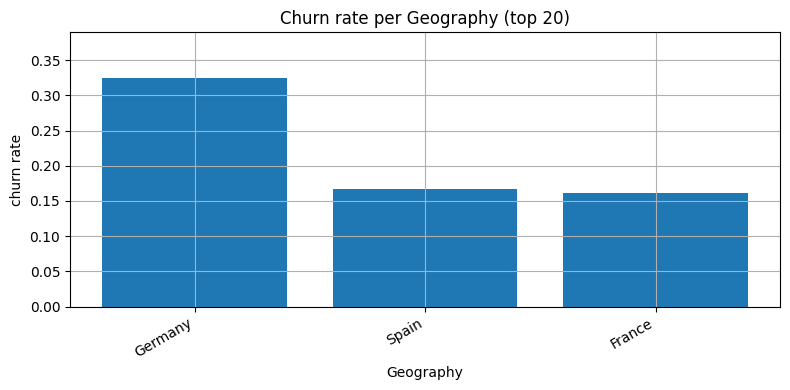

Salvata figura: C:\Users\ehuber\OneDrive - BUSINESS INTEGRATION PARTNERS SPA\projects\machine-learning-lab-2026\outputs\figures\lesson_01_churn_rate_by_geography.png


In [18]:
# Plot: churn rate per Geography
if 'Geography' in df_raw.columns:
    df_geo = churn_rate_by_category(df_raw, col='Geography', target_col=TARGET_COL)
    display(df_geo)
    plot_churn_rate_bar(df_geo, col='Geography', out_path=OUT_FIGURES_DIR / 'lesson_01_churn_rate_by_geography.png', top_n=20)

**Interpretazione (Geography)**

Nel dataset corrente:

- `Germany` ha churn rate **~32,44%** (n=2509), mentre `Spain` **~16,67%** (n=2477) e `France` **~16,17%** (n=5014).
- Questo è un classico esempio di **segmentazione**: la stessa strategia di retention potrebbe non funzionare uguale in tutti i Paesi.

Nota: questa differenza è descrittiva e può riflettere fattori latenti (prodotto diverso, pricing, canali, età media diversa, ecc.). Senza informazioni aggiuntive non va letta in chiave causale.

,Gender,churn_rate,n
0,Female,0.250715,4543
1,Male,0.164743,5457


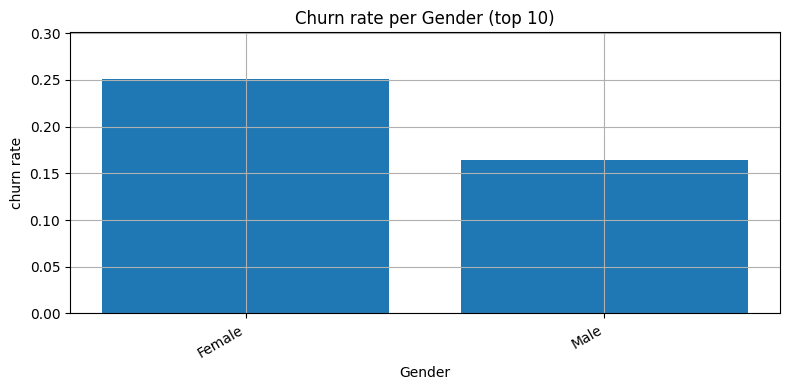

Salvata figura: C:\Users\ehuber\OneDrive - BUSINESS INTEGRATION PARTNERS SPA\projects\machine-learning-lab-2026\outputs\figures\lesson_01_churn_rate_by_gender.png


In [19]:
# Plot: churn rate per Gender
if 'Gender' in df_raw.columns:
    df_gender = churn_rate_by_category(df_raw, col='Gender', target_col=TARGET_COL)
    display(df_gender)
    plot_churn_rate_bar(df_gender, col='Gender', out_path=OUT_FIGURES_DIR / 'lesson_01_churn_rate_by_gender.png', top_n=10)

**Interpretazione (Gender)**

- Nel dataset, `Female` mostra un churn rate **~25,07%** (n=4543) vs `Male` **~16,47%** (n=5457).
- È un segnale interessante per EDA, ma in pratica può essere un **proxy** di altre differenze (es. prodotti, comportamento, età).
- Spunto in aula: controllare se la differenza permane “a parità” di `Geography` o `Age` (interazioni).

,IsActiveMember,churn_rate,n
0,0,0.268715,4849
1,1,0.142691,5151


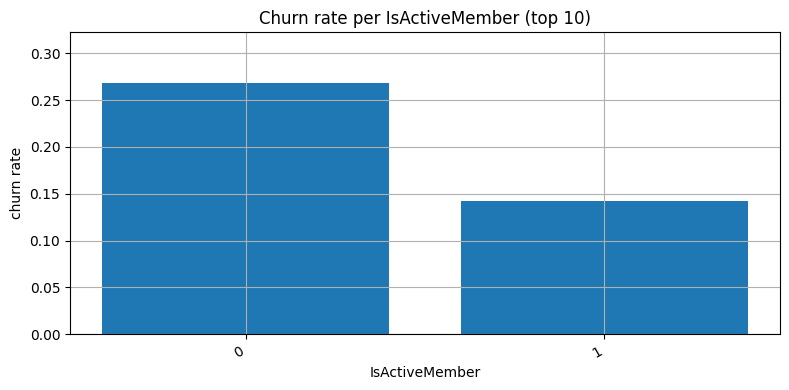

Salvata figura: C:\Users\ehuber\OneDrive - BUSINESS INTEGRATION PARTNERS SPA\projects\machine-learning-lab-2026\outputs\figures\lesson_01_churn_rate_by_isactivemember.png


In [25]:
# Plot: churn rate per IsActiveMember (variabile binaria)
if 'IsActiveMember' in df_raw.columns:
    df_rate = churn_rate_by_category(df_raw, col='IsActiveMember', target_col=TARGET_COL)
    display(df_rate)
    plot_churn_rate_bar(
        df_rate,
        col='IsActiveMember',
        out_path=OUT_FIGURES_DIR / 'lesson_01_churn_rate_by_isactivemember.png',
        top_n=10,
    )

**Interpretazione (IsActiveMember)**

- `IsActiveMember=0`: churn **~26,87%** (n=4849)
- `IsActiveMember=1`: churn **~14,27%** (n=5151)

Questa feature ha un’interpretazione “business” naturale: l’**engagement**/attività è associata a minore churn. In EDA può essere interessante verificare se questa differenza è stabile anche dentro altri segmenti (es. per `Geography` o per `NumOfProducts`).

,Complain,churn_rate,n
0,1,0.995108,2044
1,0,0.000503,7956


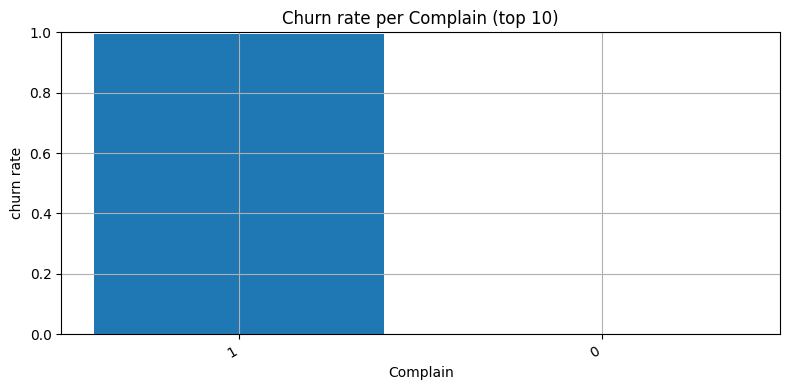

Salvata figura: C:\Users\ehuber\OneDrive - BUSINESS INTEGRATION PARTNERS SPA\projects\machine-learning-lab-2026\outputs\figures\lesson_01_churn_rate_by_complain.png


In [26]:
# Plot: churn rate per Complain (variabile binaria)
if 'Complain' in df_raw.columns:
    df_rate = churn_rate_by_category(df_raw, col='Complain', target_col=TARGET_COL)
    display(df_rate)
    plot_churn_rate_bar(
        df_rate,
        col='Complain',
        out_path=OUT_FIGURES_DIR / 'lesson_01_churn_rate_by_complain.png',
        top_n=10,
    )

**Interpretazione critica (Complain = possibile leakage)**

Qui vediamo un pattern quasi “troppo bello per essere vero”:

- `Complain=1`: churn **~99,51%** (n=2044)
- `Complain=0`: churn **~0,05%** (n=7956)

Questo suggerisce che `Complain` potrebbe essere una variabile **post-evento** (es. un reclamo registrato quando il cliente è già in fase di uscita) o comunque molto vicina temporalmente alla churn.

In EDA, le azioni sensate sono:

- verificare la **definizione** della variabile e la timeline (quando è osservabile?)
- controllare se ci sono incongruenze (es. valori impossibili, cambi di definizione nel tempo, missing anomali)
- decidere se trattarla come “segnale operativo tardivo” (utile per analisi) oppure come informazione non utilizzabile in scenari di previsione anticipata.

### 4.4 Correlazioni e relazioni bivariate (solo esplorative)

- Le **correlazioni** tra feature possono suggerire ridondanza o gruppi di variabili legate.
- La correlazione con il target può dare un’idea (grezza) di *cosa si muove insieme*, ma **non implica causalità** e va letta con cautela.
- Attenzione: alcune variabili potrebbero riflettere eventi “post-churn” (leakage).

,corr_with_target
Complain,0.995693
Age,0.285296
IsActiveMember,-0.156356
Balance,0.118577
NumOfProducts,-0.047611
CreditScore,-0.026771
Tenure,-0.013656
EstimatedSalary,0.012490
HasCrCard,-0.006976
Satisfaction Score,-0.005849


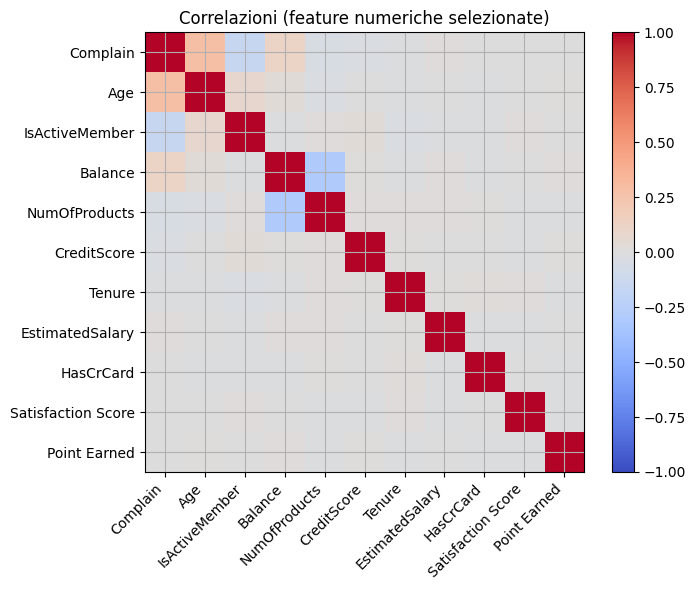

Salvata figura: C:\Users\ehuber\OneDrive - BUSINESS INTEGRATION PARTNERS SPA\projects\machine-learning-lab-2026\outputs\figures\lesson_01_correlation_heatmap.png


In [21]:
# Correlazione (numeriche) con il target
num_cols_all = df_raw.select_dtypes(include='number').columns.tolist()
if TARGET_COL in num_cols_all:
    num_cols_all = [c for c in num_cols_all if c != TARGET_COL]

# Rimuoviamo colonne ID-like dalla matrice numerica, se presenti (spesso non informative)
id_like_to_drop = [c for c in ['RowNumber', 'CustomerId'] if c in df_raw.columns]
num_cols_for_corr = [c for c in num_cols_all if c not in id_like_to_drop]

corr_with_target = df_raw[num_cols_for_corr + [TARGET_COL]].corr(numeric_only=True)[TARGET_COL].drop(TARGET_COL)
corr_table = corr_with_target.reindex(corr_with_target.abs().sort_values(ascending=False).index)
display(corr_table.to_frame('corr_with_target'))

# Heatmap delle correlazioni tra numeriche (top 12 per |corr con target|)
top_corr_cols = corr_table.abs().head(12).index.tolist()
corr_mat = df_raw[top_corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_mat.values, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(top_corr_cols)))
ax.set_yticks(range(len(top_corr_cols)))
ax.set_xticklabels(top_corr_cols, rotation=45, ha='right')
ax.set_yticklabels(top_corr_cols)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Correlazioni (feature numeriche selezionate)')
fig.tight_layout()
out_path = OUT_FIGURES_DIR / 'lesson_01_correlation_heatmap.png'
fig.savefig(out_path, dpi=150)
plt.show()
print('Salvata figura:', out_path)

**Interpretazione (correlazioni)**

- La tabella mostra la correlazione (Pearson) tra feature numeriche e `Exited`. Qui `Complain` domina con **corr ≈ 0,996**: altro segnale forte di possibile leakage.
- Tra le feature “più plausibili” vediamo `Age` (**≈ 0,285**), `IsActiveMember` (**≈ -0,156**) e `Balance` (**≈ 0,119**).
- La heatmap aiuta anche a vedere **collinearità** tra feature (ridondanza) e gruppi di variabili che “si muovono insieme”.

Avvertenze importanti:

- Pearson cattura soprattutto relazioni *lineari*; una relazione non-lineare può avere correlazione bassa ma essere comunque informativa.
- Per categoriche codificate numericamente, la correlazione può essere fuorviante: va interpretata con cautela.

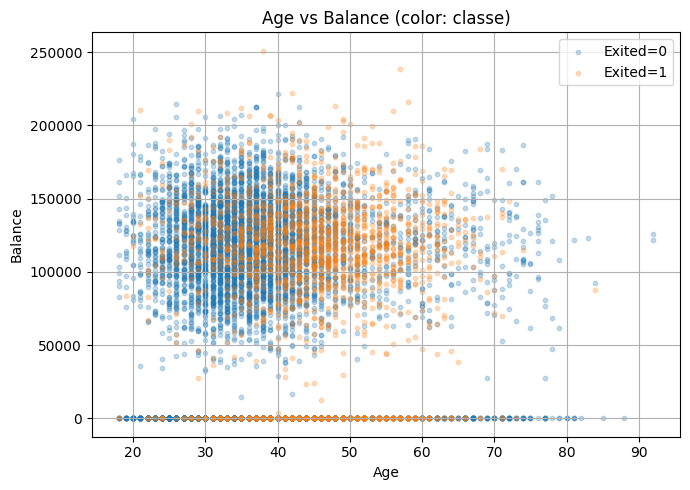

Salvata figura: C:\Users\ehuber\OneDrive - BUSINESS INTEGRATION PARTNERS SPA\projects\machine-learning-lab-2026\outputs\figures\lesson_01_age_vs_balance_scatter.png


In [22]:
# Scatter bivariato (esempio): Age vs Balance, colorato per classe
if 'Age' in df_raw.columns and 'Balance' in df_raw.columns:
    fig, ax = plt.subplots(figsize=(7, 5))
    for cls, color in [(0, 'tab:blue'), (1, 'tab:orange')]:
        sub = df_raw.loc[df_raw[TARGET_COL] == cls, ['Age', 'Balance']].dropna()
        ax.scatter(sub['Age'], sub['Balance'], s=10, alpha=0.25, c=color, label=f'{TARGET_COL}={cls}')
    ax.set_title('Age vs Balance (color: classe)')
    ax.set_xlabel('Age')
    ax.set_ylabel('Balance')
    ax.legend()
    fig.tight_layout()
    out_path = OUT_FIGURES_DIR / 'lesson_01_age_vs_balance_scatter.png'
    fig.savefig(out_path, dpi=150)
    plt.show()
    print('Salvata figura:', out_path)

**Interpretazione (scatter Age vs Balance)**

- Questo grafico aiuta a vedere *insieme* due feature e capire se le differenze tra classi si concentrano in certe regioni del piano.
- Si nota una linea di punti a `Balance=0`: è una struttura particolare del dataset (molti clienti con saldo nullo). In EDA è utile trattare `Balance==0` come un **segmento** a parte, oltre a guardare `Balance` come continuo.
- I churner tendono a concentrarsi su età più alte e saldi più elevati, ma la sovrapposizione resta ampia: è un segnale che le relazioni sono complesse e vanno lette con più viste/segmentazioni.

In [23]:
# Salviamo un piccolo riassunto EDA come artifact (utile per lezioni successive)
import json

eda_summary = {
    'n_rows': int(n_rows),
    'n_cols': int(n_cols),
    'target_col': TARGET_COL,
    'churn_rate': float(df_raw[TARGET_COL].mean()),
    'id_like_cols': id_like_cols,
}

# Aggiungiamo qualche tabella “top” se presente Geography
if 'Geography' in df_raw.columns:
    geo_rate = churn_rate_by_category(df_raw, col='Geography', target_col=TARGET_COL)
    eda_summary['churn_rate_by_geography_top'] = geo_rate.head(10).to_dict(orient='records')

# Correlazioni con target (top 10)
eda_summary['corr_with_target_top'] = (
    corr_table.abs().head(10).to_frame('abs_corr')
    .join(corr_table.to_frame('corr'), how='left')
    .reset_index()
    .rename(columns={'index': 'feature'})
    .to_dict(orient='records')
)

summary_path = OUT_CONFIG_DIR / 'lesson_01_eda_summary.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(eda_summary, f, ensure_ascii=False, indent=2)
print('Salvato riassunto EDA:', summary_path)

Salvato riassunto EDA: C:\Users\ehuber\OneDrive - BUSINESS INTEGRATION PARTNERS SPA\projects\machine-learning-lab-2026\outputs\config\lesson_01_eda_summary.json


**Artifact (riassunto EDA su disco)**

Abbiamo salvato un piccolo riassunto in `outputs/config/lesson_01_eda_summary.json`. È utile perché:

- rende l’EDA **riproducibile** senza dipendere dallo stato del kernel
- permette di controllare rapidamente numeri chiave (churn rate, segmenti top, correlazioni)
- è un esempio concreto di comunicazione via artifact: possiamo ripartire da file su disco anche con kernel “pulito”.

**Mini-sintesi EDA (messaggi chiave)**

- Churn rate complessivo: **20,38%** (sbilanciamento ~80/20).
- Segmenti forti: `Geography` (Germany **32,44%**), `Gender` (Female **25,07%**), `IsActiveMember` (0 **26,87%** vs 1 **14,27%**).
- Feature numeriche con segnale: `Age` e `Balance` (effetti visibili ma con sovrapposizione).
- Variabile sospetta: `Complain` (quasi deterministica) → verificare timeline e definizione per rischio leakage.
- Colonne da trattare con cura: `RowNumber`/`CustomerId` (ID-like), `Surname` (alta cardinalità).

### Discussione

Domande guida (da discutere in aula):
- Il target è sbilanciato (~80/20): come cambia il modo in cui comunichereste i risultati (tassi, conteggi, confronto tra segmenti)?
- Quali feature sembrano più diverse tra `Exited=0` e `Exited=1` (es. `Age`, `Balance`, `IsActiveMember`)? In che direzione e di quanto?
- `Complain` sembra quasi deterministica: quali indizi vi fanno pensare a leakage? Che controllo “di processo” fareste sui dati?
- Il churn rate cambia molto per `Geography` (Germany > Spain/France): quali ipotesi plausibili possono spiegare la differenza?
- `Surname` ha cardinalità molto alta: quali rischi comporta in un’analisi per categorie? Che verifiche fareste per capire se porta informazione o solo rumore?
- Se doveste proporre 2–3 azioni di retention, su quali segmenti le concentrereste e perché?

## 5. Esercizi (EDA guidata)

1. [easy] Calcola la percentuale di churn per `Geography` e ordina le categorie. (Suggerimento: usa `groupby` + `mean` sul target.)
2. [easy] Visualizza un boxplot di `Balance` per classe `Exited`.
3. [medium] Costruisci una tabella di churn rate per decili di `Age` (usa `pd.qcut`) e commenta quali fasce sembrano più a rischio.
4. [medium] Scegli 3 feature e discuti (in 5 righe) perché potrebbero essere associate al churn *alla luce di grafici e tabelle EDA* (senza parlare di causalità).
5. [medium] Cerca colonne potenzialmente ‘pericolose’ (leakage) e motiva la scelta. Quali segnali cercheresti?

## 6. Riepilogo

- Il churn è descritto dal target binario `Exited` e nel dataset vale **20,38%**.
- L’EDA serve a capire qualità del dato (missingness, duplicati, ID-like), distribuzioni e differenze tra classi.
- Segmenti con tassi diversi (`Geography`, `Gender`, `IsActiveMember`) suggeriscono dove guardare più a fondo e come impostare una discussione “business”.
- Alcune colonne possono nascondere leakage (es. `Complain`): è cruciale controllare definizioni e timeline.
- Gli artifact salvati in `outputs/` rendono l’analisi ripetibile e indipendente dallo stato del kernel.